In [9]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt


Transforming the images to tensor for PyTorch processing and Loading Dataset

In [10]:
transform = transforms.Compose([
    transforms.ToTensor()
])
dataset_path = "/kaggle/input/datasetcnnneww" 
dataset = torchvision.datasets.ImageFolder(root=dataset_path, transform=transform)

Display Basic Statistics

In [11]:
numClassess = len(dataset.classes)
numImages = len(dataset)
classsCnts = Counter(dataset.targets)

print(f"Dataset contains {numImages} images across {numClassess} classes.")
print(f"Classes: {dataset.classes}")
print(f"Number of images per class: {dict(classsCnts)}")

Dataset contains 30000 images across 3 classes.
Classes: ['dogs', 'food', 'vehicles']
Number of images per class: {0: 10000, 1: 10000, 2: 10000}


Creation of a weighted sampler to balance class distribution and use it in a DataLoader

In [12]:
from torch.utils.data import DataLoader, WeightedRandomSampler
classSmplCounts = np.array(list(classsCnts.values()))
weights = 1.0 / classSmplCounts
samplesWts = [weights[t] for t in dataset.targets]
sampler = WeightedRandomSampler(samplesWts, len(samplesWts))
trainLoader = DataLoader(dataset, batchSizee=32, sampler=sampler)
targets = torch.tensor(dataset.targets, dtype=torch.long)

Splitting the dataset into train and test sets and load them.  

In [13]:
from sklearn.model_selection import train_test_split
train_indices, test_indices = train_test_split(range(len(dataset)), test_size=0.2, stratify=dataset.targets)
trainDset = torch.utils.data.Subset(dataset, train_indices)
test_dataset = torch.utils.data.Subset(dataset, test_indices)

print(f"Training set: {len(trainDset)} images")
print(f"Testing set: {len(test_dataset)} images")

trainLoader = DataLoader(trainDset, batchSizee=32, shuffle=True)
testLoader = DataLoader(test_dataset, batchSizee=32, shuffle=False)


Training set: 24000 images
Testing set: 6000 images


Defining a ResNet-18 model with residual blocks

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_dropout=False, dropout_prob=0.5):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=dropout_prob) if use_dropout else nn.Identity()
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class ResNet18(nn.Module):
    def __init__(self, numClassess=10, use_dropout=False, dropout_prob=0.5):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self.makeLayer(64, 2, stride=1, use_dropout=use_dropout, dropout_prob=dropout_prob)
        self.layer2 = self.makeLayer(128, 2, stride=2, use_dropout=use_dropout, dropout_prob=dropout_prob)
        self.layer3 = self.makeLayer(256, 2, stride=2, use_dropout=use_dropout, dropout_prob=dropout_prob)
        self.layer4 = self.makeLayer(512, 2, stride=2, use_dropout=use_dropout, dropout_prob=dropout_prob)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, numClassess)
    def makeLayer(self, out_channels, blocks, stride, use_dropout, dropout_prob):
        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, use_dropout, dropout_prob))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels, use_dropout=use_dropout, dropout_prob=dropout_prob))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


Initializing 2 different weights to see the best fit for the model

In [15]:
def InitializeWts(model, init_type="xavier"):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            if init_type == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif init_type == "he":
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
            elif init_type == "normal":
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

In [16]:
trainnTransforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

valTransforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
dataset_path = "/kaggle/input/datasetcnnneww"
trainDset = torchvision.datasets.ImageFolder(root=dataset_path, transform=trainnTransforms)
valDset = torchvision.datasets.ImageFolder(root=dataset_path, transform=valTransforms)
trainSize = int(0.8 * len(trainDset))
valSize = len(trainDset) - trainSize
trainDset, valDset = random_split(trainDset, [trainSize, valSize])
batchSizee = 32
trainLoader = DataLoader(trainDset, batchSizee=batchSizee, shuffle=True)
valLosder = DataLoader(valDset, batchSizee=batchSizee, shuffle=False)

Early stopping definition if there is no improvement in models accuracy

In [17]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
    def shouldStop(self, valLoass):
        if valLoass < self.best_loss - self.min_delta:
            self.best_loss = valLoass
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience

Training Model Module

In [18]:
import time
import torch
def trainModel(model, trainLoader, valLosder, optimizer, criterion, scheduler, earlyStopping, epochs=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    bestValuesAcc = 0

    history = {
        'trainAcc': [],
        'valAcc': [],
        'trainLoss': [],
        'valLoass': []
    }
    epochTimes = []
    for epoch in range(epochs):
        startTimes = time.time()
        model.train()
        trainLoss, correct, total = 0, 0, 0
        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            trainLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        trainAccuracyy = 100 * correct / total
        model.eval()
        valLoass, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in valLosder:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoass += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)
        valAccuracies = 100 * correct / total
        if valAccuracies > bestValuesAcc:
            bestValuesAcc = valAccuracies
        history['trainLoss'].append(trainLoss / len(trainLoader))
        history['trainAcc'].append(trainAccuracyy)
        history['valLoass'].append(valLoass / len(valLosder))
        history['valAcc'].append(valAccuracies)
        scheduler.step(valLoass)
        epochTTime = time.time() - startTimes
        epochTimes.append(epochTTime)
        if earlyStopping.shouldStop(valLoass):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
        print(f"Epoch [{epoch+1}/{epochs}]: Train Loss: {trainLoss/len(trainLoader):.4f}, "
              f"Train Acc: {trainAccuracyy:.2f}%, Val Loss: {valLoass/len(valLosder):.4f}, "
              f"Val Acc: {valAccuracies:.2f}%, Time: {epochTTime:.2f} sec")
    return model, history, bestValuesAcc

In [19]:
wtInitiMethods = ["xavier", "he"]
criterion = nn.CrossEntropyLoss()
learningRate = 0.01
best_init = None
besAcc = 0
optimizerHistories={}
for init in wtInitiMethods:
    print(f"\nTraining with {init} initialization\n")    
    model = ResNet18(numClassess=3, use_dropout=True, dropout_prob=0.3)
    InitializeWts(model, init)
    optimizer = optim.SGD(model.parameters(), lr=learningRate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2) 
    earlyStopping = EarlyStopping(patience=3, min_delta=0.01)
    trainedModel,history, valAcc = trainModel(model, trainLoader, valLosder, optimizer, criterion, scheduler, earlyStopping, epochs=3)
    optimizerHistories[init] = history
    optimizerHistories[init] = {
        'trainAcc': history['trainAcc'],
        'valAcc': history['valAcc'],
        'trainLoss': history['trainLoss'],
        'valLoass': history['valLoass']
    }
    if valAcc > besAcc:
        besAcc = valAcc
        best_init = init
print(f"Best Weight Initialization: {best_init} with {besAcc}% accuracy")


Training with xavier initialization

Epoch [1/3]: Train Loss: 0.6154, Train Acc: 76.78%, Val Loss: 0.4123, Val Acc: 84.73%, Time: 137.89 sec
Epoch [2/3]: Train Loss: 0.4123, Train Acc: 84.08%, Val Loss: 0.3687, Val Acc: 85.85%, Time: 80.09 sec
Epoch [3/3]: Train Loss: 0.3565, Train Acc: 86.30%, Val Loss: 0.3490, Val Acc: 86.58%, Time: 81.95 sec

Training with he initialization

Epoch [1/3]: Train Loss: 0.5888, Train Acc: 77.74%, Val Loss: 0.4301, Val Acc: 82.80%, Time: 79.65 sec
Epoch [2/3]: Train Loss: 0.4133, Train Acc: 84.33%, Val Loss: 0.3621, Val Acc: 85.48%, Time: 82.25 sec
Epoch [3/3]: Train Loss: 0.3428, Train Acc: 86.86%, Val Loss: 0.3298, Val Acc: 87.50%, Time: 80.51 sec
Best Weight Initialization: he with 87.5% accuracy


Evaluation of the model

In [20]:
def modelEvaluation(model, testLoader, criterion):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    correct, total = 0, 0
    testLOss = 0
    with torch.no_grad():
        for images, labels in testLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            testLOss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    accuracy = 100 * correct / total
    avgLoss = testLOss / len(testLoader)
    print(f"Test Loss: {avgLoss:.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy
testLoader = valLosder
modelEvaluation(trainedModel, testLoader, criterion)

Test Loss: 0.3345
Test Accuracy: 87.42%


87.41666666666667

Plot training and validation accuracy/loss for different weight initializations.  

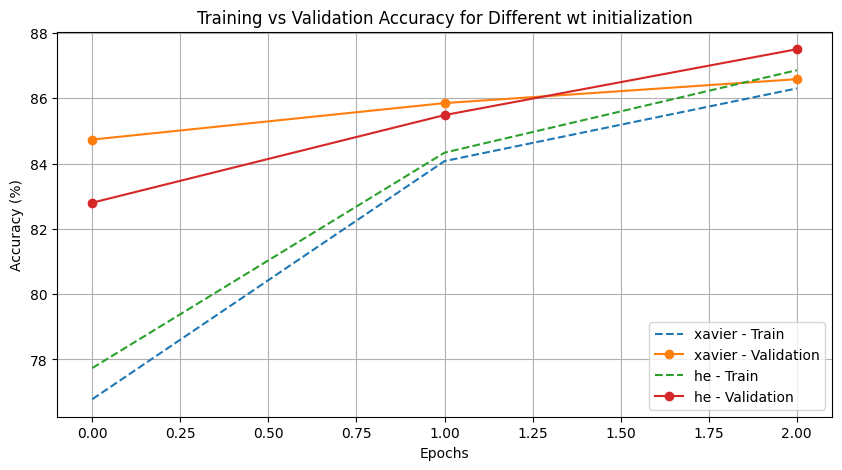

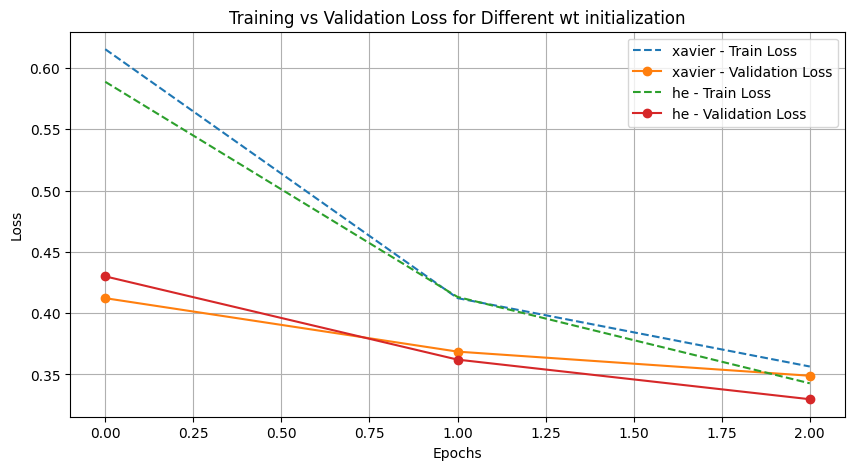

In [21]:
plt.figure(figsize=(10, 5))
for optimizerName, history in optimizerHistories.items():
    plt.plot(history['trainAcc'], label=f'{optimizerName} - Train', linestyle='dashed')
    plt.plot(history['valAcc'], label=f'{optimizerName} - Validation', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training vs Validation Accuracy for Different wt initialization')
plt.grid()
plt.show()
plt.figure(figsize=(10, 5))
for optimizerName, history in optimizerHistories.items():
    plt.plot(history['trainLoss'], label=f'{optimizerName} - Train Loss', linestyle='dashed')
    plt.plot(history['valLoass'], label=f'{optimizerName} - Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss for Different wt initialization')
plt.grid()
plt.show()

Plot the confusion matrix as a heatmap with class labels

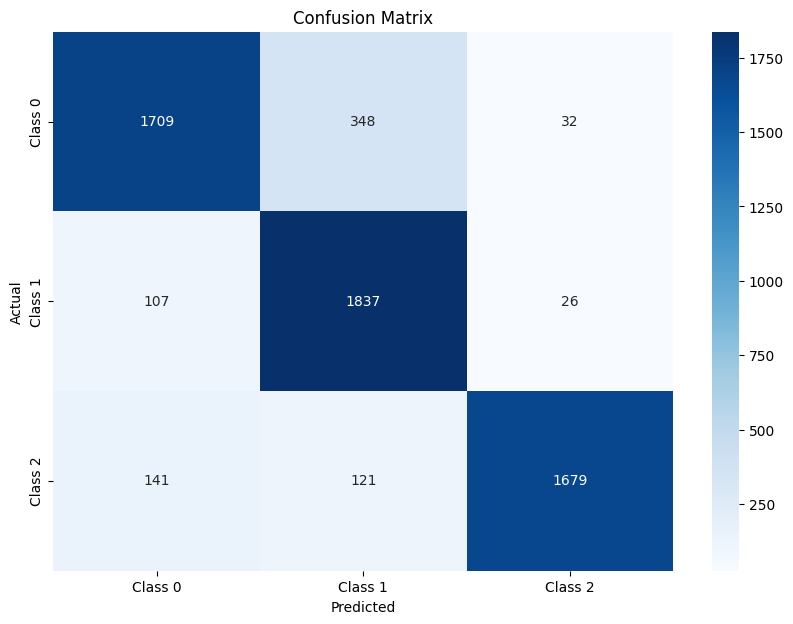

In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
classNamess = [f'Class {i}' for i in range(numClassess)]  
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classNamess, yticklabels=classNamess)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

keeping he as the wt initialization verifying for 3 optimizers to see the best fit

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_dropout=False, dropout_prob=0.5):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=dropout_prob) if use_dropout else nn.Identity()
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class ResNet18(nn.Module):
    def __init__(self, numClassess=10, use_dropout=False, dropout_prob=0.5):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)  
        self.layer1 = self.makeLayer(64, 2, stride=1, use_dropout=use_dropout, dropout_prob=dropout_prob)
        self.layer2 = self.makeLayer(128, 2, stride=2, use_dropout=use_dropout, dropout_prob=dropout_prob)
        self.layer3 = self.makeLayer(256, 2, stride=2, use_dropout=use_dropout, dropout_prob=dropout_prob)
        self.layer4 = self.makeLayer(512, 2, stride=2, use_dropout=use_dropout, dropout_prob=dropout_prob)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, numClassess)
        
    def makeLayer(self, out_channels, blocks, stride, use_dropout, dropout_prob):
        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, use_dropout, dropout_prob))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels, use_dropout=use_dropout, dropout_prob=dropout_prob))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

Initialize Weights (He Initialization)

In [27]:
def InitializeWts(model, init_type="he"):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            if init_type == "he":
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')

Data Augmentation and Loading

In [28]:
trainnTransforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
valTransforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
dataset_path =  "/kaggle/input/datasetcnnneww" 
trainDset = torchvision.datasets.ImageFolder(root=dataset_path, transform=trainnTransforms)
valDset = torchvision.datasets.ImageFolder(root=dataset_path, transform=valTransforms)
trainSize = int(0.8 * len(trainDset))
valSize = len(trainDset) - trainSize
trainDset, valDset = random_split(trainDset, [trainSize, valSize])
batchSizee = 32
trainLoader = DataLoader(trainDset, batchSizee=batchSizee, shuffle=True)
valLosder = DataLoader(valDset, batchSizee=batchSizee, shuffle=False)

Train model module

In [29]:
def trainModel(model, trainLoader, valLosder, optimizer, criterion, scheduler, earlyStopping, epochs=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    history = {
        'trainAcc': [],
        'valAcc': [],
        'trainLoss': [],
        'valLoass': []
    }
    epochTimes = []  
    for epoch in range(epochs):
        startTimes = time.time()  
        model.train()
        trainLoss, correct, total = 0, 0, 0
        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            trainLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        trainAccuracyy = 100 * correct / total
        model.eval()
        valLoass, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in valLosder:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoass += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        valAccuracies = 100 * correct / total
        history['trainLoss'].append(trainLoss / len(trainLoader))
        history['trainAcc'].append(trainAccuracyy)
        history['valLoass'].append(valLoass / len(valLosder))
        history['valAcc'].append(valAccuracies)
        scheduler.step(valLoass)
        epochTTime = time.time() - startTimes
        epochTimes.append(epochTTime)
        if earlyStopping.shouldStop(valLoass):
            print(f"Early stopping triggered at epoch {epoch+1} (Time: {epochTTime:.2f} seconds)")
            break
        print(f"Epoch [{epoch+1}/{epochs}]: Train Loss: {trainLoss/len(trainLoader):.4f}, "
              f"Train Acc: {trainAccuracyy:.2f}%, Val Loss: {valLoass/len(valLosder):.4f}, "
              f"Val Acc: {valAccuracies:.2f}%, Time: {epochTTime:.2f} sec")
    return model, epochTimes, history

Define and Train the Model Using 3 Optimizers to see the best fit

In [30]:
init_method = "he"  
criterion = nn.CrossEntropyLoss()
learningRate = 0.01  
optimizerHistories = {}  

optimizer_methods = {
    "SGD": optim.SGD,
    "Adam": optim.Adam,
    "RMSprop": optim.RMSprop
}

for optimizerName, optimizer_class in optimizer_methods.items():
    print(f"\nTraining with {optimizerName} optimizer...\n")
    model = ResNet18(numClassess=3, use_dropout=True, dropout_prob=0.3)
    InitializeWts(model, init_method)
    if optimizerName in ["SGD", "RMSprop"]:
        optimizer = optimizer_class(model.parameters(), lr=learningRate, momentum=0.9, weight_decay=5e-4)
    else:
        optimizer = optimizer_class(model.parameters(), lr=learningRate, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)
    earlyStopping = EarlyStopping(patience=3, min_delta=0.01)
    startTimes = time.time()
    trainedModel, epochTimes, history = trainModel(model, trainLoader, valLosder, optimizer, criterion, scheduler, earlyStopping, epochs=3)
    if isinstance(history, dict):
        optimizerHistories[optimizerName] = history
    else:
        print(f"Unexpected format for history: {type(history)} - {history}")
    total_time = time.time() - startTimes
    epochTimes = [float(t) for t in epochTimes]
    print(f"\nEpoch-wise Training Times for {optimizerName}:")
    for i, t in enumerate(epochTimes, 1):
        print(f"  Epoch {i}: {t:.2f} seconds")
    print(f"\nTotal training time for {optimizerName}: {total_time:.2f} seconds")
    valAcc = max(optimizerHistories[optimizerName]['valAcc'], default=0)
    print(f"\nBest validation accuracy with {optimizerName}: {valAcc:.2f}%")


Training with SGD optimizer...



/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/3]: Train Loss: 0.5689, Train Acc: 77.97%, Val Loss: 0.4687, Val Acc: 81.72%, Time: 82.01 sec
Epoch [2/3]: Train Loss: 0.4114, Train Acc: 84.34%, Val Loss: 0.3829, Val Acc: 85.48%, Time: 82.04 sec
Epoch [3/3]: Train Loss: 0.3525, Train Acc: 86.40%, Val Loss: 0.3606, Val Acc: 85.87%, Time: 82.59 sec

Epoch-wise Training Times for SGD:
  Epoch 1: 82.01 seconds
  Epoch 2: 82.04 seconds
  Epoch 3: 82.59 seconds

Total training time for SGD: 246.66 seconds

Best validation accuracy with SGD: 85.87%

Training with Adam optimizer...

Epoch [1/3]: Train Loss: 0.7189, Train Acc: 72.56%, Val Loss: 0.6048, Val Acc: 75.50%, Time: 83.87 sec
Epoch [2/3]: Train Loss: 0.5129, Train Acc: 79.86%, Val Loss: 0.5375, Val Acc: 79.28%, Time: 80.72 sec
Epoch [3/3]: Train Loss: 0.4816, Train Acc: 80.97%, Val Loss: 0.5620, Val Acc: 78.03%, Time: 79.81 sec

Epoch-wise Training Times for Adam:
  Epoch 1: 83.87 seconds
  Epoch 2: 80.72 seconds
  Epoch 3: 79.81 seconds

Total training time for Adam: 244.42

Plot training and validation accuracy/loss for different optimizer with He initialization 

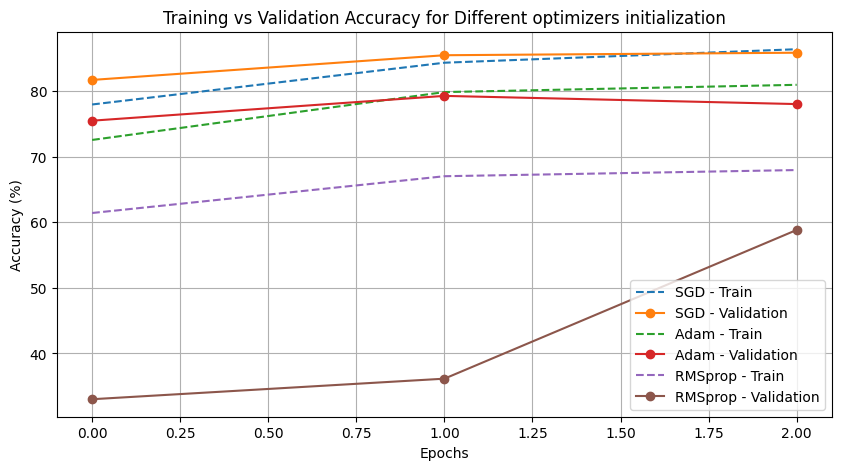

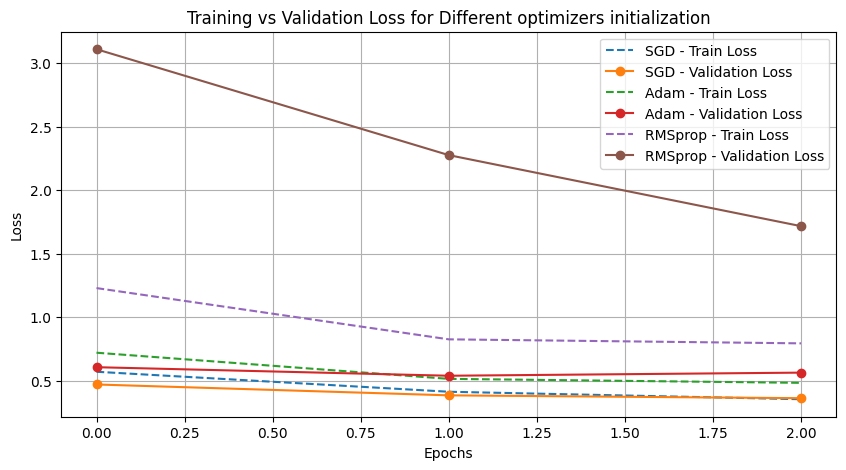

In [32]:
plt.figure(figsize=(10, 5))
for optimizerName, history in optimizerHistories.items():
    plt.plot(history['trainAcc'], label=f'{optimizerName} - Train', linestyle='dashed')
    plt.plot(history['valAcc'], label=f'{optimizerName} - Validation', marker='o')

plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training vs Validation Accuracy for Different optimizers initialization')
plt.grid()
plt.show()
plt.figure(figsize=(10, 5))
for optimizerName, history in optimizerHistories.items():
    plt.plot(history['trainLoss'], label=f'{optimizerName} - Train Loss', linestyle='dashed')
    plt.plot(history['valLoass'], label=f'{optimizerName} - Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss for Different optimizers initialization')
plt.grid()
plt.show()


Evaluation of the model, generating predictions, and plotting of the confusion matrix.  

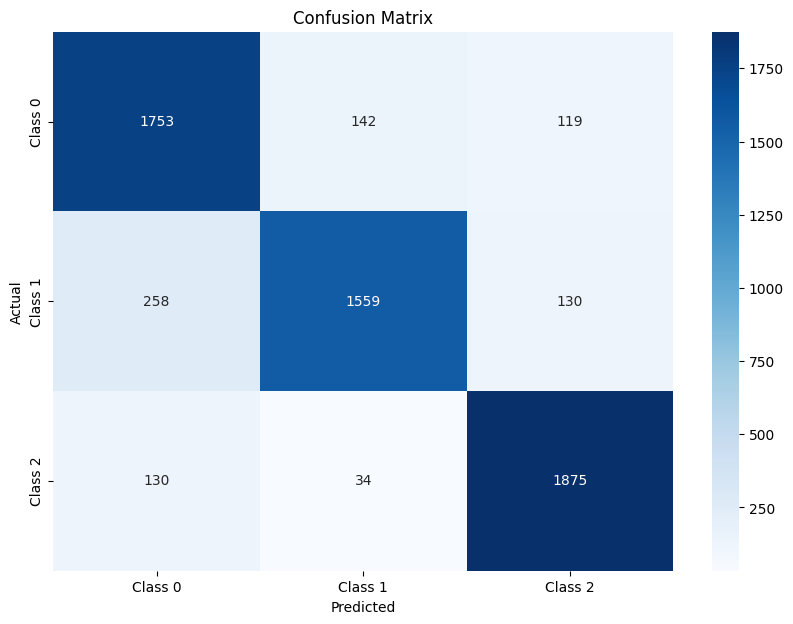

In [41]:
def modelEvaluationGraph(model, dataloader, criterion, device='cuda'):
    model.to(device)  
    model.eval() 
    allPreds = []
    allLabels = []
    total_loss = 0.0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)  
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)  
            allPreds.extend(preds.cpu().numpy()) 
            allLabels.extend(labels.cpu().numpy()) 
    return allPreds, allLabels 
testPreds, testLabels = modelEvaluationGraph(trainedModel, testLoader, criterion)
if not isinstance(testPreds, list) or not isinstance(testLabels, list):
    raise TypeError("modelEvaluation() should return two lists: testPreds and testLabels")
cm = confusion_matrix(testLabels, testPreds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classNamess, yticklabels=classNamess)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

keeping SGD as the optimizer, he as the weight initialization and verifying for batch sizes to see which is the best fit among 32 and 64

In [42]:
class VGG16(nn.Module):
    def __init__(self, numClassess=3):
        super(VGG16, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))  
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, numClassess)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


weight initialization

In [43]:
def InitializeWts(model, init_type="he"):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            if init_type == "he":
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')

Model training

In [45]:
import time
import torch
def trainModel(model, trainLoader, valLosder, optimizer, criterion, scheduler, earlyStopping, batchSizee, epochs=2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    epochTimes = []
    history = {"trainAcc": [], "valAcc": [], "trainLoss": [], "valLoass": []}
    for epoch in range(epochs):
        startTimes = time.time()
        model.train()
        trainLoss, correct, total = 0, 0, 0
        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            trainLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        trainAccuracyy = 100 * correct / total
        history["trainAcc"].append(trainAccuracyy)
        history["trainLoss"].append(trainLoss / len(trainLoader))
        model.eval()
        valLoass, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in valLosder:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoass += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        valAccuracies = 100 * correct / total
        history["valAcc"].append(valAccuracies)
        history["valLoass"].append(valLoass / len(valLosder))
        scheduler.step(valLoass)
        epochTTime = time.time() - startTimes
        epochTimes.append(epochTTime)
        if earlyStopping.shouldStop(valLoass):
            print(f"Early stopping triggered at epoch {epoch+1} (Time: {epochTTime:.2f} seconds)")
            break
        print(f"Batch Size [{batchSizee}] - Epoch [{epoch+1}/{epochs}]: Train Loss: {history['trainLoss'][-1]:.4f}, "
              f"Train Acc: {trainAccuracyy:.2f}%, Val Loss: {history['valLoass'][-1]:.4f}, "
              f"Val Acc: {valAccuracies:.2f}%, Time: {epochTTime:.2f} sec")
    return model, epochTimes, history

In [46]:
import torch.optim as optim
import torch.nn as nn
criterion = nn.CrossEntropyLoss()
learningRate = 0.01
optimizerName = "SGD"
batchSizees = [32, 64]
optimizerHistories = {}

for batchSizee in batchSizees:
    print(f"\nTraining with {optimizerName} optimizer and batch size {batchSizee}...\n")
    model = ResNet18(numClassess=3, use_dropout=True, dropout_prob=0.3)
    InitializeWts(model, init_method)
    optimizer = optim.SGD(model.parameters(), lr=learningRate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)
    earlyStopping = EarlyStopping(patience=3, min_delta=0.01)
    startTimes = time.time()
    trainedModel, epochTimes, history = trainModel(model, trainLoader, valLosder, optimizer, criterion, scheduler, earlyStopping, batchSizee, epochs=2)
    total_time = time.time() - startTimes
    print(f"\nTotal training time for batch size {batchSizee}: {total_time:.2f} seconds")
    optimizerHistories[f"{optimizerName}_batch{batchSizee}"] = history 


Training with SGD optimizer and batch size 32...



/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Batch Size [32] - Epoch [1/2]: Train Loss: 0.5769, Train Acc: 78.05%, Val Loss: 0.4967, Val Acc: 81.22%, Time: 79.86 sec
Batch Size [32] - Epoch [2/2]: Train Loss: 0.4322, Train Acc: 83.75%, Val Loss: 0.3401, Val Acc: 87.20%, Time: 78.73 sec

Total training time for batch size 32: 158.60 seconds

Training with SGD optimizer and batch size 64...

Batch Size [64] - Epoch [1/2]: Train Loss: 0.5861, Train Acc: 77.74%, Val Loss: 0.4643, Val Acc: 82.95%, Time: 77.55 sec
Batch Size [64] - Epoch [2/2]: Train Loss: 0.4001, Train Acc: 84.49%, Val Loss: 0.3630, Val Acc: 86.17%, Time: 77.61 sec

Total training time for batch size 64: 155.17 seconds


Graph plotting against 2 batches

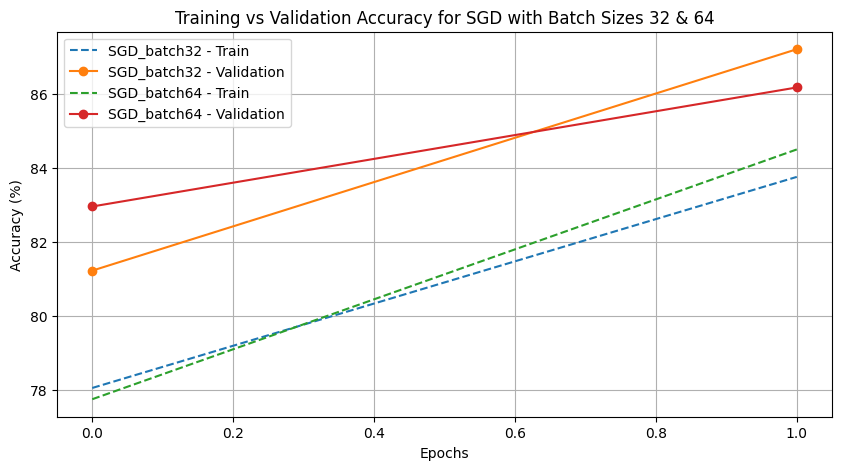

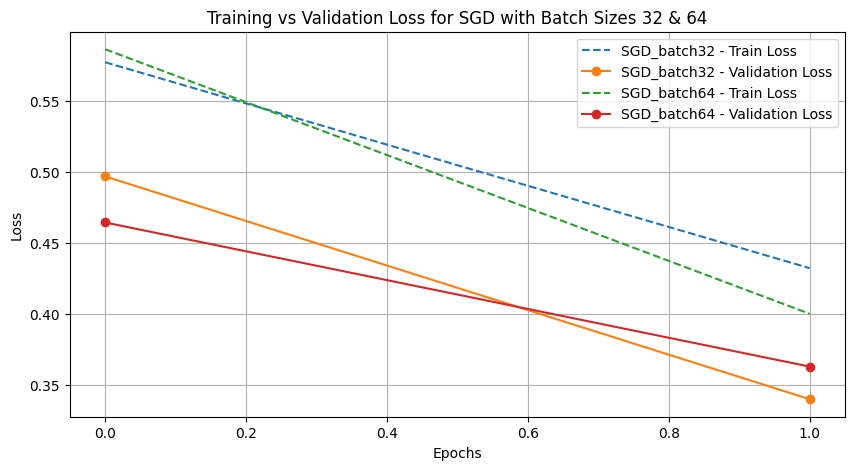

In [47]:
plt.figure(figsize=(10, 5))
for key, history in optimizerHistories.items():
    plt.plot(history['trainAcc'], label=f'{key} - Train', linestyle='dashed')
    plt.plot(history['valAcc'], label=f'{key} - Validation', marker='o')

plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training vs Validation Accuracy for SGD with Batch Sizes 32 & 64')
plt.grid()
plt.show
plt.figure(figsize=(10, 5))

for key, history in optimizerHistories.items():
    plt.plot(history['trainLoss'], label=f'{key} - Train Loss', linestyle='dashed')
    plt.plot(history['valLoass'], label=f'{key} - Validation Loss', marker='o')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss for SGD with Batch Sizes 32 & 64')
plt.grid()
plt.show()

Confusion matrix for the latest model

Test Accuracy: 86.37%, Test Loss: 0.3672


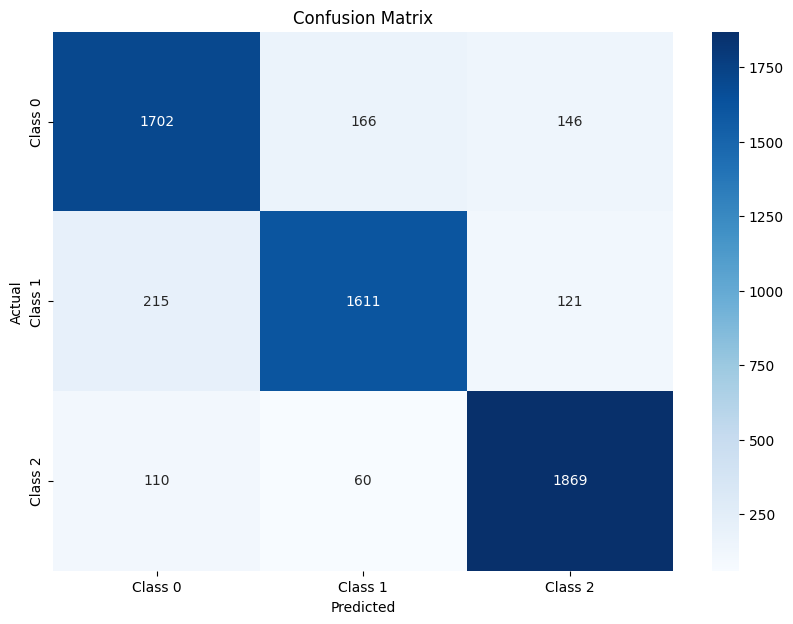

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
def modelEvaluation(model, data_loader, criterion):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    allPreds, allLabels = [], []
    testLOss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            testLOss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            allPreds.extend(predicted.cpu().numpy())
            allLabels.extend(labels.cpu().numpy())
    test_accuracy = 100 * correct / total
    print(f"Test Accuracy: {test_accuracy:.2f}%, Test Loss: {testLOss / len(data_loader):.4f}")
    return allPreds, allLabels 
testPreds, testLabels = modelEvaluation(trainedModel, testLoader, criterion)

cm = confusion_matrix(testLabels, testPreds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classNamess, yticklabels=classNamess)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

SGD, HE, Batch 32 - best model

In [49]:
batchSizee = 32

In [50]:
import time
import torch
def trainModel(model, trainLoader, valLosder, optimizer, criterion, scheduler, earlyStopping, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    bestValuesAcc = 0
    history = {
        'trainAcc': [],
        'valAcc': [],
        'trainLoss': [],
        'valLoass': []
    }
    epochTimes = []
    for epoch in range(epochs):
        startTimes = time.time()
        model.train()
        trainLoss, correct, total = 0, 0, 0
        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            trainLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        trainAccuracyy = 100 * correct / total
        model.eval()
        valLoass, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in valLosder:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoass += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        valAccuracies = 100 * correct / total
        if valAccuracies > bestValuesAcc:
            bestValuesAcc = valAccuracies
        history['trainLoss'].append(trainLoss / len(trainLoader))
        history['trainAcc'].append(trainAccuracyy)
        history['valLoass'].append(valLoass / len(valLosder))
        history['valAcc'].append(valAccuracies)
        scheduler.step(valLoass)
        epochTTime = time.time() - startTimes
        epochTimes.append(epochTTime)
        if earlyStopping.shouldStop(valLoass):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        print(f"Epoch [{epoch+1}/{epochs}]: Train Loss: {trainLoss/len(trainLoader):.4f}, "
              f"Train Acc: {trainAccuracyy:.2f}%, Val Loss: {valLoass/len(valLosder):.4f}, "
              f"Val Acc: {valAccuracies:.2f}%, Time: {epochTTime:.2f} sec")
    return model, history, bestValuesAcc 


In [51]:
import time
import torch

def trainModel(model, trainLoader, valLosder, optimizer, criterion, scheduler, earlyStopping, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    bestValuesAcc = 0
    history = {
        'trainAcc': [],
        'valAcc': [],
        'trainLoss': [],
        'valLoass': []
    }
    epochTimes = [] 
    for epoch in range(epochs):
        startTimes = time.time()
        model.train()
        trainLoss, correct, total = 0, 0, 0
        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            trainLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        trainAccuracyy = 100 * correct / total
        model.eval()
        valLoass, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in valLosder:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoass += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)
        valAccuracies = 100 * correct / total
        if valAccuracies > bestValuesAcc:
            bestValuesAcc = valAccuracies
        history['trainLoss'].append(trainLoss / len(trainLoader))
        history['trainAcc'].append(trainAccuracyy)
        history['valLoass'].append(valLoass / len(valLosder))
        history['valAcc'].append(valAccuracies)
        scheduler.step(valLoass)
        epochTTime = time.time() - startTimes
        epochTimes.append(epochTTime)
        if earlyStopping.shouldStop(valLoass):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
        print(f"Epoch [{epoch+1}/{epochs}]: Train Loss: {trainLoss/len(trainLoader):.4f}, "
              f"Train Acc: {trainAccuracyy:.2f}%, Val Loss: {valLoass/len(valLosder):.4f}, "
              f"Val Acc: {valAccuracies:.2f}%, Time: {epochTTime:.2f} sec")
    return model, history, bestValuesAcc

In [52]:
wtInitiMethods = ["he"]
criterion = nn.CrossEntropyLoss()
learningRate = 0.01
best_init = None
besAcc = 0
optimizerHistories={}
for init in wtInitiMethods:
    print(f"\nTraining with {init} initialization...\n")
    model = ResNet18(numClassess=3, use_dropout=True, dropout_prob=0.3)
    InitializeWts(model, init)
    optimizer = optim.SGD(model.parameters(), lr=learningRate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)
    earlyStopping = EarlyStopping(patience=3, min_delta=0.01)
    trainedModel,history, valAcc = trainModel(model, trainLoader, valLosder, optimizer, criterion, scheduler, earlyStopping, epochs=5)
    optimizerHistories[init] = history
    optimizerHistories[init] = {
        'trainAcc': history['trainAcc'],
        'valAcc': history['valAcc'],
        'trainLoss': history['trainLoss'],
        'valLoass': history['valLoass']
    }

    if valAcc > besAcc:
        besAcc = valAcc
        best_init = init
print(f"Best Weight Initialization: {best_init} with {besAcc}% accuracy")


Training with he initialization...



/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/5]: Train Loss: 0.5929, Train Acc: 77.61%, Val Loss: 0.4293, Val Acc: 83.58%, Time: 77.81 sec
Epoch [2/5]: Train Loss: 0.4057, Train Acc: 84.62%, Val Loss: 0.3936, Val Acc: 85.53%, Time: 77.98 sec
Epoch [3/5]: Train Loss: 0.3366, Train Acc: 86.90%, Val Loss: 0.2752, Val Acc: 89.50%, Time: 78.86 sec
Epoch [4/5]: Train Loss: 0.3106, Train Acc: 88.15%, Val Loss: 0.3745, Val Acc: 86.00%, Time: 79.62 sec
Epoch [5/5]: Train Loss: 0.2940, Train Acc: 89.02%, Val Loss: 0.2478, Val Acc: 90.88%, Time: 77.73 sec
Best Weight Initialization: he with 90.88333333333334% accuracy


Evaluate the model

In [55]:
def modelEvaluation(model, testLoader, criterion):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    correct, total = 0, 0
    testLOss = 0
    with torch.no_grad():
        for images, labels in testLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            testLOss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    accuracy = 100 * correct / total
    avgLoss = testLOss / len(testLoader)

    print(f"Test Loss: {avgLoss:.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")
testLoader = valLosder
modelEvaluation(trainedModel, testLoader, criterion)

Test Loss: 0.2431
Test Accuracy: 91.12%


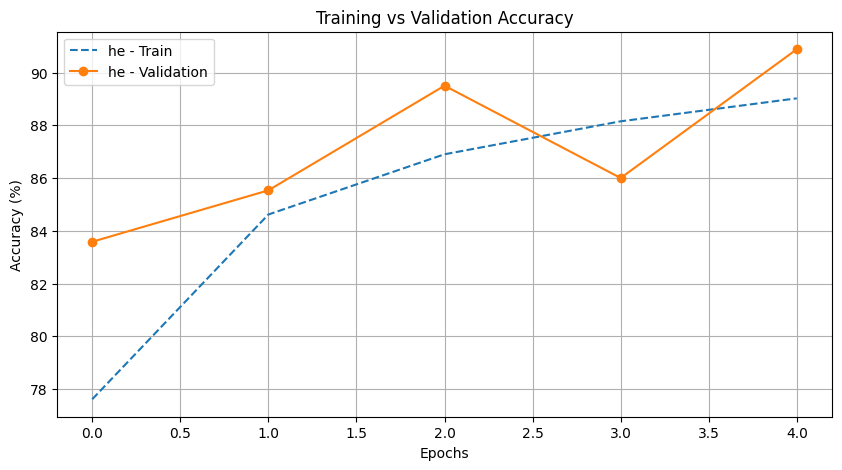

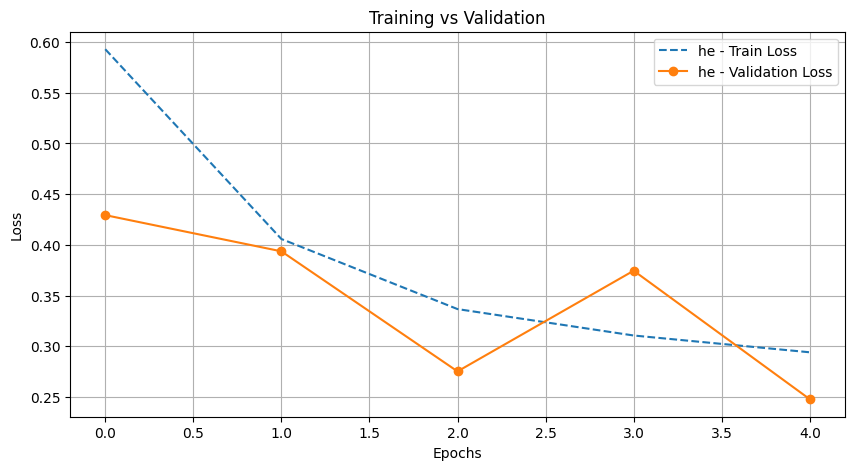

In [56]:
plt.figure(figsize=(10, 5))
for optimizerName, history in optimizerHistories.items():
    plt.plot(history['trainAcc'], label=f'{optimizerName} - Train', linestyle='dashed')
    plt.plot(history['valAcc'], label=f'{optimizerName} - Validation', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.grid()
plt.show()
plt.figure(figsize=(10, 5))
for optimizerName, history in optimizerHistories.items():
    plt.plot(history['trainLoss'], label=f'{optimizerName} - Train Loss', linestyle='dashed')
    plt.plot(history['valLoass'], label=f'{optimizerName} - Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation')
plt.grid()
plt.show()


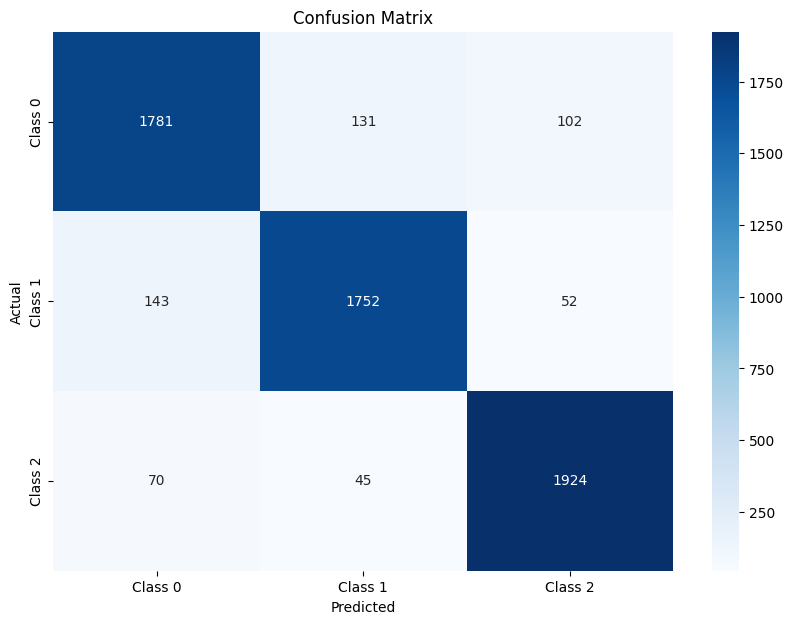

In [57]:
def modelEvaluationGraph(model, dataloader, criterion, device='cuda'):
    model.to(device) 
    model.eval() 
    allPreds = []
    allLabels = []
    total_loss = 0.0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device) 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)  
            allPreds.extend(preds.cpu().numpy())  
            allLabels.extend(labels.cpu().numpy())  

    return allPreds, allLabels  
testPreds, testLabels = modelEvaluationGraph(trainedModel, testLoader, criterion)
if not isinstance(testPreds, list) or not isinstance(testLabels, list):
    raise TypeError("modelEvaluation() should return two lists: testPreds and testLabels")

cm = confusion_matrix(testLabels, testPreds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classNamess, yticklabels=classNamess)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [60]:
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, _ = precision_recall_fscore_support(testLabels, testPreds, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Precision: 0.9093, Recall: 0.9095, F1 Score: 0.9094


In [61]:
torch.save(model.state_dict(), "a1_part1_rsaravan_kisorese_resnet_wt.pt")

Step 4:  Discussion and Conclusion

1.
VGG - It is a deep convolutional neural network that uses a small 3 X 3 filters stacked together to make a deeper network.  Using a small filter like 3 X 3 helps us capture the fine details while keeping the parameters manageable.  Stacking of the layers allows the model to learn complex patters.  Max pooling reduce the image size while keeping the important features and finally the fully connected layers make predictions.  Due to its huge number of parameters VGG is slow and more memory intensive.
<br>
ResNet - This solves the vanishing gradient problem which happens while training very deep networks.  If the gradient becomes too small or too large the learning becomes ineffective.  Residual connections allow info to skip certain layers instead of passing through every single one.  Instead of learning from scratch the ResNet learns the difference between input and the desired output.  It keeps a shortcut where the input skips certain layers and is added back laters this helps the network train faster without losing important information.
<br>
2.  Performance impact based on Regularization and optimization techniques :
VGG - 
Weight Initialization - Since out of Xavier and He, He initialization showed better accuracy due to faster convergence and gradient updated, it was utilized for the best model.
Regularization - Weight decay L2 regularization, 5e-4 helped us prevent the overfitting of the model.
Optimization - SGD with momentum 0.9 improved the speed and stability
Learning Rate Scheduling - It adjusted with the learning rated when the validation loss peaked.
Early stopping halted the training when no improvement was seen avoiding any overfitting.
VGG Achieved around 86.77 % validation accuracy and 86.58% test accuracy
ResNEt achieved around 90.36% validation accuracy and 86.58% test accuracy.

Regularization L2, data augmentation, optimization SGD momentum, and adaptive learning rates significantly improved the performance
<br>
3. Metrics Comparison
	<br>•	VGG-16:
	<br>•	Precision: 87.41%
	<br>•	Recall: 86.52%
	<br>•	F1 Score: 86.40%
	<br>•	Best validation accuracy: 86.77%
	<br>•	ResNet-18:
	<br>•	Precision: 90.93%
	<br>•	Recall: 90.95%
	<br>•	F1 Score: 90.94%
	<br>•	Best validation accuracy: 90.88%
<br>We can infer that the ResNet model out performs VGG-16 model in all the key metrics, and better final validation accuracy approximately around 4.1% higher
In terms of accuracy both the models improve over every epoch.  Resnet reaches 90.88% accuracy whereas VGG-16 model stops at 86.77%
VGG-16  shows a smaller gap between training and validation accuracy, which is a indicator of stable generalization
In terms of loss trends both the models have consistently lowered the loss for every epoch
Resnet achieves lower loss validation compared to VGG 16
From the graphs we can see that the VGG - 16 shows a smoother decline in loss, whereas the resNet model has slight fluctuations 
VGG - 16 takes around 106 - 111 seconds per epoch and resnet around 77 to 80 seconds per epoch.
Residual connections in ResNet helps prevent the vanishing gradient problem, which leads to better optimization and deeper learning.  ResNet achieves higher accuracy in fewer epochs than VGG.  Lower loss and better precision recall metrics indicated the superior generalization.
<br>
4.  Key differences between the VGG and ResNet:
ResNet outperforms VGG models with higher accuracy, while also maintaining less training time compared to the VGG model.  The resNet model achieves lower validation loss, indicating a better generalization.  The better validation accuracy of resnet lies in the residual connections which prevent vanishing gradient, improved convergence speed and enhanced accuracy, which the VGG model lacks.  These connections play an integral role in training a deeper neural network to train more efficiently and generalize better.  Overall resnet is preferred model due to its better performance, faster training and better generalization.